# Penguin cytochrome-b analysis

# This notebook: reads penguin cytochrome-b DNA sequences, translates them into amino acid sequences, calculates GC content and molecular weight, adds those values to a penguin body mass dataframe, and creates visualizations.

In [1]:
from Bio import SeqIO
from Bio.Data import CodonTable
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
## Load input files
# Two primary data files: 
# 1) a CSV with penguin body mass values 
# 2) a FASTA file with cytochrome-b DNA sequences
# I combine these files later in the workflow
penguins_df = pd.read_csv("penguins_mass.csv")
penguins_df.head()

,species,mass
0,Aptenodytes forsteri,28.00
1,Aptenodytes patagonicus,13.40
2,Eudyptes chrysocome,2.80
3,Eudyptes chrysolophus,4.50
4,Eudyptes sclateri,4.25


## Functions

# The next section includes helper functions that are needed for hte assignment: 
1) reading sequences
2) translating DNA into amino acids
3) calculating molecular weight
4) calculating GC content.

In [3]:
# 1) Dr. X’s function
def get_sequences_from_file(fasta_fn):
    sequence_data_dict = {}
    for record in SeqIO.parse(fasta_fn, "fasta"):
        description = record.description.split()
        species_name = description[1] + " " + description[2]
        sequence_data_dict[species_name] = record.seq

    return sequence_data_dict

## Function: get_sequences_from_file()

  The get_sequences_from_file() function reads a FASTA file containing cytochrome-b DNA sequences, stores them in a dictionary

- **Input:**  
  `fasta_fn` – a string representing the file path to the FASTA file containing cytochrome-b DNA sequences

- **Output:**  
  A dictionary where:
 - keys are species names (Genus species)  
 - values are DNA sequences (Bio.Seq objects)

- **Purpose:**  
  The function uses BioPython’s `SeqIO.parse()` to read all sequence records within the FASTA file. It pulls the species name from the header and stores each sequence in a dictionary- the sequences can then be accessed by the associated species name

In [4]:
# 2) Translation function using a loop
def translate_dna_loop(dna_seq):
    mito_table = CodonTable.unambiguous_dna_by_name["Vertebrate Mitochondrial"]
    
    dna_seq = str(dna_seq).upper()
    aa_seq = ""

    for i in range(0, len(dna_seq), 3):
        codon = dna_seq[i:i+3]

        if len(codon) < 3:
            break

        if codon in mito_table.stop_codons:
            break

        aa_seq += mito_table.forward_table.get(codon, "")

    return aa_seq

In [5]:
# Testing the loop 
cytb_seqs = get_sequences_from_file("penguins_cytb.fasta")

for species, seq in cytb_seqs.items():
    print(species, translate_dna_loop(seq)[:15])
    break

Aptenodytes forsteri MAPNLRKSHPLLKMI


## Function: translate_dna_loop()

This function translates the DNA sequence to the amino acid sequence using a loop function

- The DNA sequence is read in groups of three nucleotides   
- Translation is made using the Vertebrate Mitochondrial codon table  
- Translation stops if a stop codon is encountered  
- An amino acid sequnce is the output

In [6]:
# 3) Alternative translation function
def translate_dna_biopython(dna_seq):
    return str(dna_seq.translate(table="Vertebrate Mitochondrial", to_stop=True))

In [7]:
# Testing alternative translation function
for species, seq in cytb_seqs.items():
    print(species, translate_dna_biopython(seq)[:15])
    break

Aptenodytes forsteri MAPNLRKSHPLLKMI


In [8]:
# Comparing to ensure the functions give same output (True)
for species, seq in cytb_seqs.items():
    loop_version = translate_dna_loop(seq)
    bio_version = translate_dna_biopython(seq)

    print(loop_version[:20])
    print(bio_version[:20])
    print(loop_version == bio_version)
    break

MAPNLRKSHPLLKMINNSLI
MAPNLRKSHPLLKMINNSLI
True


## Function: translate_dna_biopython()

My generated function translates the DNA sequence to an amino acid sequence using the `translate()` BioPython method.

- Uses the Vertebrate Mitochondrial codon table  
- The `to_stop=True` argument --> removes the stop codon  

In [9]:
# 4) Molecular weight function
def get_molecular_weight(aa_seq):
    aa_seq = str(aa_seq).replace("*", "")
    analyzed_seq = ProteinAnalysis(aa_seq)
    return analyzed_seq.molecular_weight()

In [10]:
# Test molecular weight function
for species, seq in cytb_seqs.items():
    aa_seq = translate_dna_loop(seq)
    print(species, get_molecular_weight(aa_seq))
    break

Aptenodytes forsteri 42459.602100000004


## Function: get_molecular_weight()

This function will determine the molecular weight of an amino acid sequence using the `ProteinAnalysis' function of BioPython

- Input: amino acid sequence  
- Output: molecular weight

Removes stop codon symbol before calculating molecular weight

In [11]:
# 5) GC content function
def get_gc_content(dna_seq):
    dna_seq = str(dna_seq).upper()
    g_count = dna_seq.count("G")
    c_count = dna_seq.count("C")

    return (g_count + c_count) / len(dna_seq)

In [12]:
# Test GC content function 
for species, seq in cytb_seqs.items():
    print(species, get_gc_content(seq))
    break

Aptenodytes forsteri 0.48381452318460194


## Function: get_gc_content()

This function calculates the GC content of a DNA sequence.

- Input: DNA sequence  
- Output: proportion of nucleotides that are either G or C  

GC content is calculated as:
(G + C) / total sequence length

In [13]:
# 6) Addding extra columns (molecular weight, GC content)

penguins_df["molecular_weight"] = float("nan")
penguins_df["GC_content"] = float("nan")

penguins_df

,species,mass,molecular_weight,GC_content
0,Aptenodytes forsteri,28.00,NaN,NaN
1,Aptenodytes patagonicus,13.40,NaN,NaN
2,Eudyptes chrysocome,2.80,NaN,NaN
3,Eudyptes chrysolophus,4.50,NaN,NaN
4,Eudyptes sclateri,4.25,NaN,NaN
5,Eudyptula minor,1.60,NaN,NaN
6,Pygoscelis adeliae,4.60,NaN,NaN
7,Pygoscelis antarctica,4.10,NaN,NaN
8,Pygoscelis papua,6.10,NaN,NaN
9,Spheniscus demersus,3.20,NaN,NaN


## Add empty columns

I am adding two new columns to the penguin body mass dataframe:

- `molecular_weight`
- `GC_content`

I am initially filling with `NaN` until I add more details in next step

In [14]:
# 7) Filling in the data frame through a loop
for species, dna_seq in cytb_seqs.items():
    aa_seq = translate_dna_loop(dna_seq)
    mol_weight = get_molecular_weight(aa_seq)
    gc_content = get_gc_content(dna_seq)

    penguins_df.loc[penguins_df["species"] == species, "molecular_weight"] = mol_weight
    penguins_df.loc[penguins_df["species"] == species, "GC_content"] = gc_content

penguins_df

,species,mass,molecular_weight,GC_content
0,Aptenodytes forsteri,28.00,42459.6021,0.483815
1,Aptenodytes patagonicus,13.40,42563.7067,0.496938
2,Eudyptes chrysocome,2.80,42475.5753,0.511811
3,Eudyptes chrysolophus,4.50,42445.5493,0.509186
4,Eudyptes sclateri,4.25,42475.5753,0.508311
5,Eudyptula minor,1.60,42491.6408,0.492563
6,Pygoscelis adeliae,4.60,42458.6140,0.490814
7,Pygoscelis antarctica,4.10,42404.5423,0.477690
8,Pygoscelis papua,6.10,42595.8759,0.471566
9,Spheniscus demersus,3.20,42431.5490,0.482940


## Fill the DataFrame

For each species, the cytochrome-b DNA sequence was translated to the amino acid sequence. The molecular weight of the amino acid sequence and the GC content of the DNA sequence are calculated --> added to the dataframe.

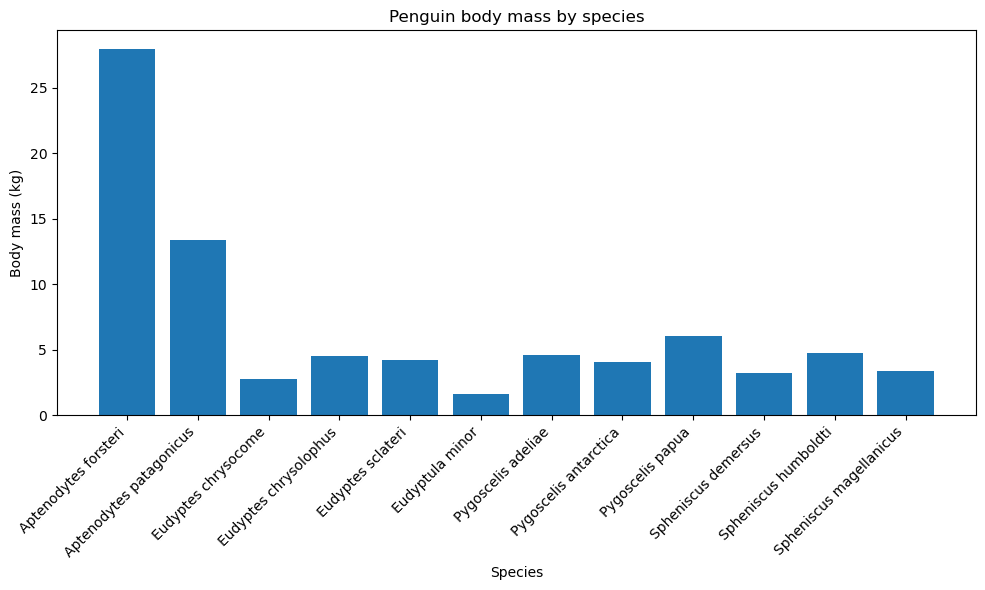

In [15]:
# 8) Generate bar plot: body mass by species
plt.figure(figsize=(10, 6))

x = range(len(penguins_df))
plt.bar(x, penguins_df["mass"])

plt.xticks(x, penguins_df["species"], rotation=45, ha="right")
plt.xlabel("Species")
plt.ylabel("Body mass (kg)")
plt.title("Penguin body mass by species")

plt.tight_layout()
plt.show()

## Interpretation of body mass plot

The produced bar chart compares average adult body mass across the penguin species provided. There are clear size differences among species, with some penguins substantially larger (Aptenodytes forsteri, Aptenodytes patagonicus) than others (Eudyptula minor, Eudyptes chrysocome).

In [16]:
# Identify smallest sequence
penguins_df.sort_values("mass")

,species,mass,molecular_weight,GC_content
5,Eudyptula minor,1.60,42491.6408,0.492563
2,Eudyptes chrysocome,2.80,42475.5753,0.511811
9,Spheniscus demersus,3.20,42431.5490,0.482940
11,Spheniscus magellanicus,3.40,42459.6021,0.482065
7,Pygoscelis antarctica,4.10,42404.5423,0.477690
4,Eudyptes sclateri,4.25,42475.5753,0.508311
3,Eudyptes chrysolophus,4.50,42445.5493,0.509186
6,Pygoscelis adeliae,4.60,42458.6140,0.490814
10,Spheniscus humboldti,4.75,42399.5520,0.492563
8,Pygoscelis papua,6.10,42595.8759,0.471566


## Smallest penguin species

The smallest penguin species in this dataset is Eudyptula minor.

The geographic range for this species is southern Australia and New Zealand (Google).

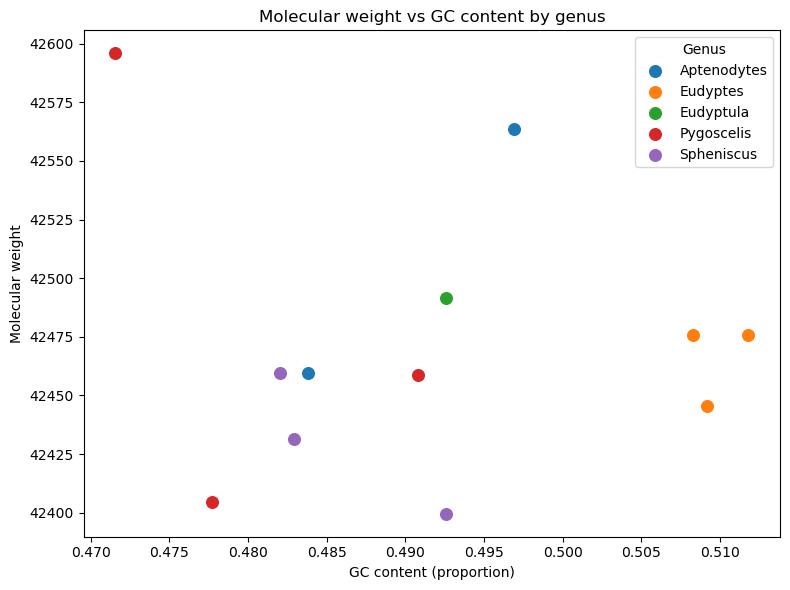

In [17]:
# 9) Making scatterplot: molecular weight vs GC content
plot_df = penguins_df.dropna(subset=["GC_content", "molecular_weight"]).copy()

plot_df["genus"] = plot_df["species"].str.split().str[0]

plt.figure(figsize=(8, 6))

for genus in plot_df["genus"].unique():
    subset = plot_df[plot_df["genus"] == genus]
    plt.scatter(
        subset["GC_content"],
        subset["molecular_weight"],
        s=70,
        label=genus
    )

plt.xlabel("GC content (proportion)")
plt.ylabel("Molecular weight")
plt.title("Molecular weight vs GC content by genus")

plt.legend(title="Genus")
plt.tight_layout()
plt.show()

## Interpretation of scatter plot

This scatter plot shows the relationship between GC content and molecular weight of the cytochrome-b protein across the penguin species provided. The molecular weight looks fairly similar across the species, while the GC content appears to show more variation. I chose to color code by genus given the overlapping labels with labeling each point.

In [18]:
# 10) Export to CSV 
penguins_df.to_csv("penguins_mass_cytb.csv", index=False)

## Export results

The final DataFrame, including species, body mass, GC content, and molecular weight, was saved as `penguins_mass_cytb.csv`.

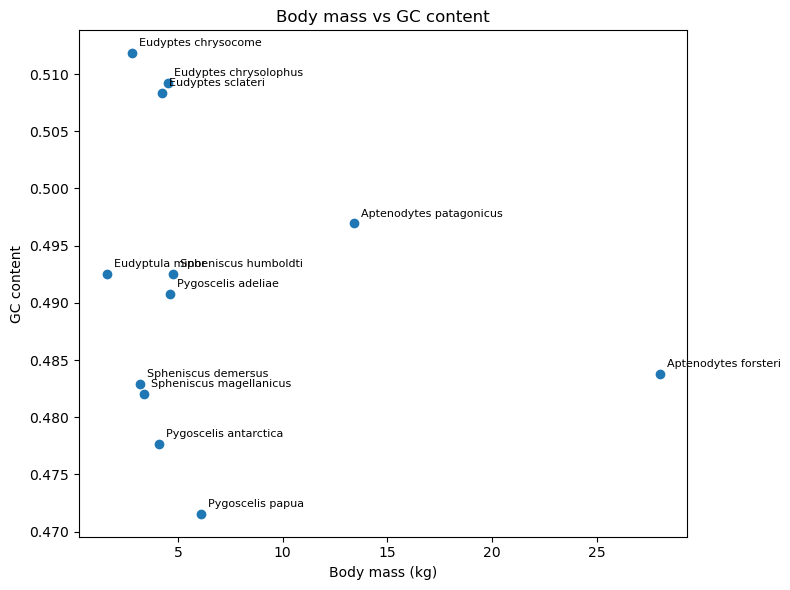

In [19]:
# 11. Extra plot: Mass vs GC content plot
plt.figure(figsize=(8, 6))
plt.scatter(penguins_df["mass"], penguins_df["GC_content"])

for _, row in penguins_df.iterrows():
    plt.annotate(
        row["species"],
        (row["mass"], row["GC_content"]),
        xytext=(5,5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Body mass (kg)")
plt.ylabel("GC content")
plt.title("Body mass vs GC content")

plt.tight_layout()
plt.show()

## Bonus analysis

This plot looks at the relationship between body mass and GC content. I do not see a particularly strong relationship between these variables.

In [20]:
# Correlation between variables
corr_gc_mw = penguins_df["GC_content"].corr(penguins_df["molecular_weight"])
corr_mass_mw = penguins_df["mass"].corr(penguins_df["molecular_weight"])

print("Correlation (GC content vs molecular weight):", corr_gc_mw)
print("Correlation (body mass vs molecular weight):", corr_mass_mw)

Correlation (GC content vs molecular weight): -0.10452155663074966
Correlation (body mass vs molecular weight): 0.15867550172155873


## Bonus analysis: Correlation

I also ran a correlation analysis to look at relationships between variables:

- GC content and molecular weight show a weak correlation, demonstrating little relationship between nucleotide composition and the protein size
- Body mass and molecular weight also show fairly little correlation; cytochrome-b protein size appears to be conserved regardless of the penguin size

## Bonus function
I made a helper function to summarize key values for each species, including body mass, GC content, and molecular weight, rounding to more 

In [21]:
# Ranking species by molecular weight
penguins_df.sort_values("molecular_weight", ascending=False)

,species,mass,molecular_weight,GC_content
8,Pygoscelis papua,6.10,42595.8759,0.471566
1,Aptenodytes patagonicus,13.40,42563.7067,0.496938
5,Eudyptula minor,1.60,42491.6408,0.492563
2,Eudyptes chrysocome,2.80,42475.5753,0.511811
4,Eudyptes sclateri,4.25,42475.5753,0.508311
11,Spheniscus magellanicus,3.40,42459.6021,0.482065
0,Aptenodytes forsteri,28.00,42459.6021,0.483815
6,Pygoscelis adeliae,4.60,42458.6140,0.490814
3,Eudyptes chrysolophus,4.50,42445.5493,0.509186
9,Spheniscus demersus,3.20,42431.5490,0.482940


## Bonus analysis: Ranking by molecular weight

I also ranked penguin species by cytochrome-b molecular weight. Differences are relatively small- it looks like this protein is relatively conserved across the penguins

Citations:
- Cock, P. J. A., et al. (2009). Biopython: freely available Python tools for computational molecular biology and bioinformatics. *Bioinformatics*, 25(11), 1422–1423.
- Biopython Tutorial and Cookbook. https://biopython.org/wiki/Documentation
- Biopython ProtParam documentation. https://biopython.org/wiki/ProtParam
- OpenAI ChatGPT 5.2 (2026). Used for guidance on Python code options and debugging.